In [1]:
# ============================
# 1. IMPORTS E CONFIGURAÇÃO
# ============================
# Esta célula reúne todas as bibliotecas usadas no projeto e define os
# parâmetros iniciais da coleta. Ao final, calcula automaticamente o
# intervalo de datas que será consultado na API do CFPB.
import requests
import pandas as pd
import numpy as np
import io
import re
import string
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Ajustes visuais leves para padronizar os gráficos do notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlepad"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


# Downloads necessários do NLTK para stopwords e lematização.
# Se o ambiente já tiver esses recursos, o NLTK apenas confirma a disponibilidade.
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ============================
# 2. PARÂMETROS GERAIS
# ============================
# DAYS_BACK controla quantos dias para trás serão considerados na coleta.
# Ajustar esse valor altera apenas o recorte temporal, mantendo o restante do pipeline.
DAYS_BACK = 90  # altere para 90, 180, 365, etc., se quiser mais histórico

BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

# Datas (hoje e limite mínimo)
today = datetime.utcnow().date()
date_received_max = today.strftime("%Y-%m-%d")
date_received_min = (today - timedelta(days=DAYS_BACK)).strftime("%Y-%m-%d")

print("Coletando dados de", date_received_min, "até", date_received_max)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Coletando dados de 2025-12-27 até 2026-03-27


/tmp/ipykernel_2747/2697610205.py:56: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow().date()


In [2]:
# ============================
# 3. COLETA DE DADOS NA API DO CFPB
# ============================
# Esta célula consulta a API pública do CFPB, pagina os resultados e monta
# um DataFrame único com as reclamações que possuem narrativa textual.
import requests
import pandas as pd
import io

BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

def fetch_complaints(date_min: str, date_max: str, max_size: int = 50000) -> pd.DataFrame:
    """
    Busca reclamações na API pública do CFPB no intervalo [date_min, date_max].
    - date_min, date_max: strings no formato 'YYYY-MM-DD'
    - max_size: número máximo total de registros desejados (vamos paginar em lotes de até 10000)
    Retorna um DataFrame com os dados.
    """

    # A API documenta retorno em json/csv/xls/xlsx e suporta paginação via 'page' e 'size'.
    PAGE_SIZE = 10000
    size = min(PAGE_SIZE, max_size)

    headers = {
        # User-Agent explícito ajuda a evitar bloqueios ou respostas 403.
        "User-Agent": "POS-TECH-Datathon/1.0 (Google Colab; contato: seu_email@exemplo.com)"
    }

    all_dfs = []
    total_fetched = 0
    page = 1

    while total_fetched < max_size:
        params = {
            "date_received_min": date_min,
            "date_received_max": date_max,
            "has_narrative": "true",
            "no_aggs": "true",
            "field": "all",
            "format": "csv",
            "size": size,
            "page": page
        }

        print(f"Buscando página {page} (size={size})...")
        resp = requests.get(BASE_URL, params=params, headers=headers, timeout=30)

        # Em caso de erro 403, a mensagem abaixo ajuda no diagnóstico rápido.
        print("Status code:", resp.status_code)
        if resp.status_code == 403:
            print("Resposta 403 - Forbidden. Tente rodar de outro ambiente (sem VPN) "
                  "ou reduzir ainda mais o size, por exemplo size=1000.")
            resp.raise_for_status()

        resp.raise_for_status()

        csv_data = io.StringIO(resp.text)
        df_page = pd.read_csv(csv_data)

        if df_page.empty:
            print("Página vazia, encerrando paginação.")
            break

        all_dfs.append(df_page)
        fetched = len(df_page)
        total_fetched += fetched
        print(f"Página {page}: {fetched} registros. Total acumulado: {total_fetched}.")

        if fetched < size:
            # Se a página retornou menos linhas do que o solicitado, chegamos ao fim.
            break

        page += 1

    if not all_dfs:
        return pd.DataFrame()

    df = pd.concat(all_dfs, ignore_index=True)
    return df

# Executa a coleta usando o intervalo definido na célula anterior.
df_raw = fetch_complaints(date_received_min, date_received_max, max_size=50000)
print("Registros brutos retornados:", df_raw.shape)
df_raw.head()


Buscando página 1 (size=10000)...
Status code: 200
Página 1: 29149 registros. Total acumulado: 29149.
Buscando página 2 (size=10000)...
Status code: 200
Página 2: 29149 registros. Total acumulado: 58298.
Registros brutos retornados: (58298, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,02/19/26,Credit card,General-purpose credit card or charge card,Fees or interest,Problem with fees,I had a CITI bank Best Buy card account ending...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",FL,32246,NaN,Consent provided,Web,02/19/26,Closed with monetary relief,Yes,NaN,19620152
1,02/24/26,Debt collection,Mortgage debt,Written notification about debt,Didn't receive enough information to verify debt,Subject : Incorrect late payment reported for ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,XXXXX,Servicemember,Consent provided,Web,02/24/26,Closed with non-monetary relief,Yes,NaN,19743943
2,01/22/26,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,"On XX/XX/year>, I used my Citi bank credit car...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",OH,45215,NaN,Consent provided,Web,01/22/26,Closed with explanation,Yes,NaN,18917331
3,01/13/26,Debt collection,Payday loan debt,Electronic communications,Frequent or repeated messages,I am submitting this complaint to report an un...,Company believes complaint caused principally ...,BlueChip Financial,IN,46835,NaN,Consent provided,Web,01/13/26,Closed with explanation,Yes,NaN,18687860
4,01/23/26,"Payday loan, title loan, personal loan, or adv...",Personal line of credit,Struggling to pay your loan,NaN,I am filing this complaint regarding my person...,NaN,Transform Credit Inc.,UT,84115,NaN,Consent provided,Web,01/23/26,Closed with explanation,Yes,NaN,18964782


In [3]:
# ============================
# 4. CRIAÇÃO DA VARIÁVEL-ALVO (SENTIMENTO)
# ============================
# Como a base não possui rótulos prontos de sentimento, esta célula cria
# a coluna 'sentiment' por meio de uma regra heurística baseada em palavras.
# O objetivo é gerar um alvo inicial para treinar o modelo supervisionado.

# Listas ampliadas de palavras associadas a cada polaridade.
positive_words = [
    "thank", "thanks", "helpful", "resolved", "great",
    "good", "excellent", "satisfied", "happy",
    "quick", "fast", "efficient", "professional",
    "appreciate", "support", "solution", "clear",
    "easy", "smooth", "success"
]

negative_words = [
    "error", "fraud", "problem", "issue", "complaint",
    "unauthorized", "wrong", "fail", "failed", "failure",
    "delay", "late", "denied", "refused", "charged",
    "fee", "billing", "overcharge", "scam", "dispute",
    "frustration", "bad", "poor", "terrible", "awful",
    "unacceptable", "difficult", "confusing", "stress",
    "harassment", "debt", "collection"
]

def rule_based_sentiment(row):
    # Converte o texto para minúsculas para facilitar a comparação com os dicionários.
    text = str(row.get("Consumer complaint narrative", "")).lower()

    # Conta quantos termos positivos e negativos aparecem no texto.
    # Mantemos uma lógica simples e transparente.
    pos_count = sum(word in text for word in positive_words)
    neg_count = sum(word in text for word in negative_words)

    # Regra binária:
    # - se houver mais sinais positivos do que negativos, classificamos como positivo;
    # - nos demais casos, mantemos como negativo.
    if pos_count > neg_count:
        return "positive"
    else:
        return "negative"

# Referência original da coleta.
df = df_raw.copy()
df["sentiment"] = df.apply(rule_based_sentiment, axis=1)

# Remove linhas sem sentimento definido (proteção adicional, embora a função atual
# sempre devolva um rótulo binário).
df = df[df["sentiment"].notna()].reset_index(drop=True)

print("Distribuição de sentimento:")
print(df["sentiment"].value_counts())


Distribuição de sentimento:
sentiment
negative    56184
positive     2114
Name: count, dtype: int64


In [4]:
# ============================
# 5. PRÉ-PROCESSAMENTO DO TEXTO
# ============================
# Nesta etapa, limpamos o texto livre das reclamações para reduzir ruído
# e padronizar a entrada que será usada pelo modelo e pelas análises finais.

TEXT_COL = "Consumer complaint narrative"

# Remove linhas sem texto antes de aplicar a limpeza.
df = df[df[TEXT_COL].notna()].reset_index(drop=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Limpa e normaliza o texto:
    - lowercase
    - remove URLs, números, pontuação
    - remove stopwords
    - aplica lematização
    """
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Mantém apenas letras e espaço
    text = re.sub(r"[^a-z\s]", " ", text)

    # Tokenização simples por espaço
    tokens = text.split()

    # Remove stopwords e lematiza
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 2
    ]

    return " ".join(tokens)

# Cria a coluna com o texto limpo que será usada no restante do notebook.
df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

# Remove entradas com texto limpo vazio (se houver).
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print("Exemplo de texto original vs limpo:")
for i in range(3):
    print("Original:", df.loc[i, TEXT_COL][:200])
    print("Limpo  :", df.loc[i, "clean_text"][:200])
    print("-" * 80)


Exemplo de texto original vs limpo:
Original: I had a CITI bank Best Buy card account ending in XXXX that was unknowingly auto renewed and fees were applied and accrued. Immediately upon discovery of this account and fees, the account was closed 
Limpo  : citi bank best buy card account ending xxxx unknowingly auto renewed fee applied accrued immediately upon discovery account fee account closed paid best buy prorated paid remaining balance directly ci
--------------------------------------------------------------------------------
Original: Subject : Incorrect late payment reported for mortgage account # XXXX Complaint : On XX/XX/year>, I made my full mortgage payment of {$970.00} by online payment/ACH/check and the payment cleared my ba
Limpo  : subject incorrect late payment reported mortgage account xxxx complaint year made full mortgage payment online payment ach check payment cleared bank date servicer xxxx xxxx xxxx xxxx reported xxxx da
-----------------------------------------

In [5]:
# ============================
# 6. SPLIT TREINO/TESTE E TOKENIZAÇÃO
# ============================
# Aqui separamos os dados para treino e teste e transformamos o texto limpo
# em sequências numéricas que podem ser consumidas pela rede neural.

X = df["clean_text"].values
y = df["sentiment"].map({"negative": 0, "positive": 1}).values

# O stratify preserva a proporção entre classes nos conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

MAX_WORDS = 20000   # tamanho máximo do vocabulário
MAX_LEN = 200       # tamanho máximo de cada sequência

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Converte os textos em sequências de índices inteiros.
seq_train = tokenizer.texts_to_sequences(X_train)
seq_test = tokenizer.texts_to_sequences(X_test)

# Pad/truncate para comprimento fixo, garantindo entrada homogênea para o modelo.
X_train_pad = pad_sequences(seq_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(seq_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("Shape X_train_pad:", X_train_pad.shape)
print("Shape X_test_pad :", X_test_pad.shape)


Shape X_train_pad: (46638, 200)
Shape X_test_pad : (11660, 200)


In [6]:
# ============================
# 7. MODELO DE DEEP LEARNING
# ============================
# A arquitetura abaixo combina camada de embedding com BiLSTM para capturar
# contexto sequencial no texto das reclamações e classificá-las em positivo/negativo.

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBED_DIM = 100      # dimensão do embedding
LSTM_UNITS = 64

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    tf.keras.layers.GlobalMaxPool1D(),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Exibe a arquitetura resumida da rede.
model.summary()

EPOCHS = 5       # ajuste conforme sua infra
BATCH_SIZE = 128

# O validation_split reserva uma parte do treino para acompanhar generalização.
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Avaliação no conjunto de teste, que não participou do treinamento.
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Acurácia em teste: {test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 286s 848ms/step - accuracy: 0.9618 - loss: 0.1662 - val_accuracy: 0.9642 - val_loss: 0.1036
Epoch 2/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 249s 759ms/step - accuracy: 0.9700 - loss: 0.0857 - val_accuracy: 0.9831 - val_loss: 0.0501
Epoch 3/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 249s 721ms/step - accuracy: 0.9867 - loss: 0.0397 - val_accuracy: 0.9882 - val_loss: 0.0332
Epoch 4/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 250s 763ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9837 - val_loss: 0.0392
Epoch 5/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 249s 761ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.9910 - val_loss: 0.0331
Acurácia em teste: 0.9901


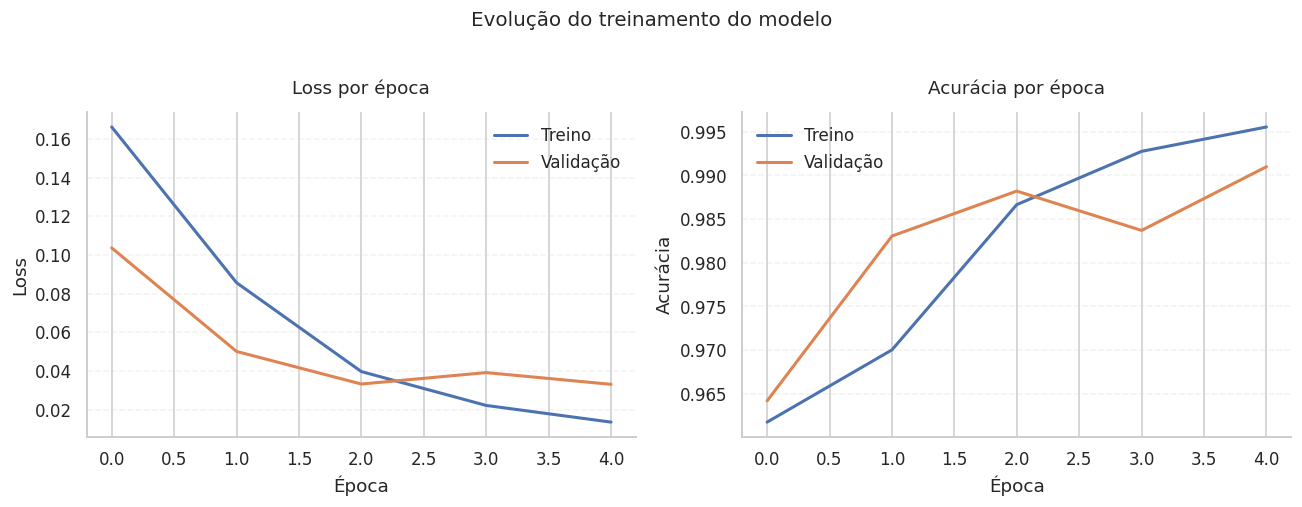

365/365 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step


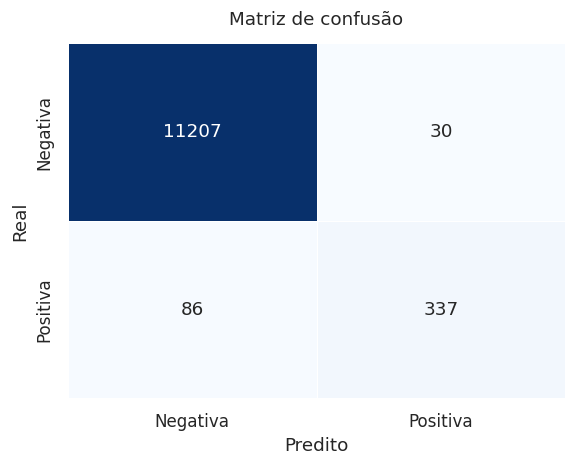


Relatório de classificação:
              precision    recall  f1-score   support

    negative       0.99      1.00      0.99     11237
    positive       0.92      0.80      0.85       423

    accuracy                           0.99     11660
   macro avg       0.96      0.90      0.92     11660
weighted avg       0.99      0.99      0.99     11660



In [7]:
# ============================
# 8. GRÁFICOS DE PERFORMANCE DO MODELO
# ============================
# Esta célula mostra a evolução do treinamento e a qualidade das previsões
# no conjunto de teste por meio de curvas e matriz de confusão.

# Curvas de loss e accuracy ao longo das épocas.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Loss
axes[0].plot(history.history["loss"], label="Treino", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validação", linewidth=2)
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

# Accuracy
axes[1].plot(history.history["accuracy"], label="Treino", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Validação", linewidth=2)
axes[1].set_title("Acurácia por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

fig.suptitle("Evolução do treinamento do modelo", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Gera probabilidades e converte em classes binárias com limiar de 0.5.
y_pred_prob = model.predict(X_test_pad).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Matriz de confusão para visualizar acertos e erros por classe.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.4, 4.4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Negativa", "Positiva"],
    yticklabels=["Negativa", "Positiva"]
)
plt.title("Matriz de confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# Relatório textual com precision, recall e f1-score.
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

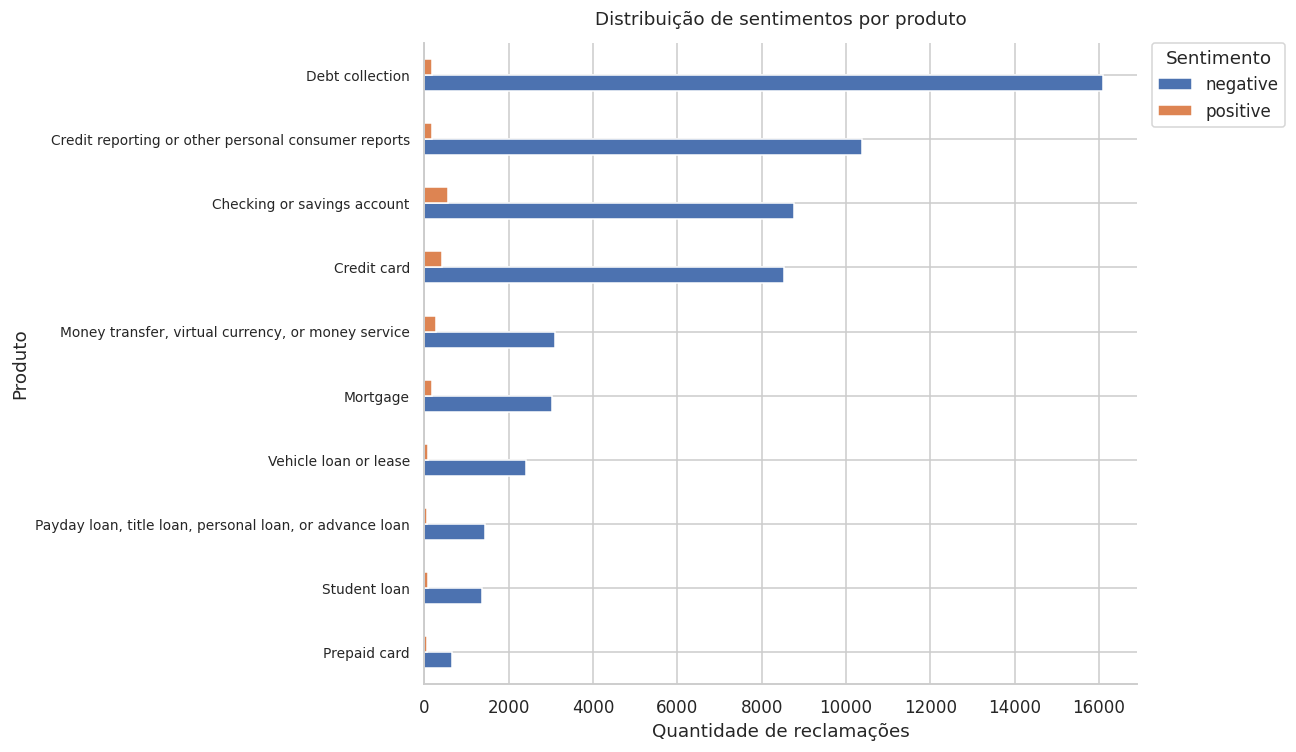

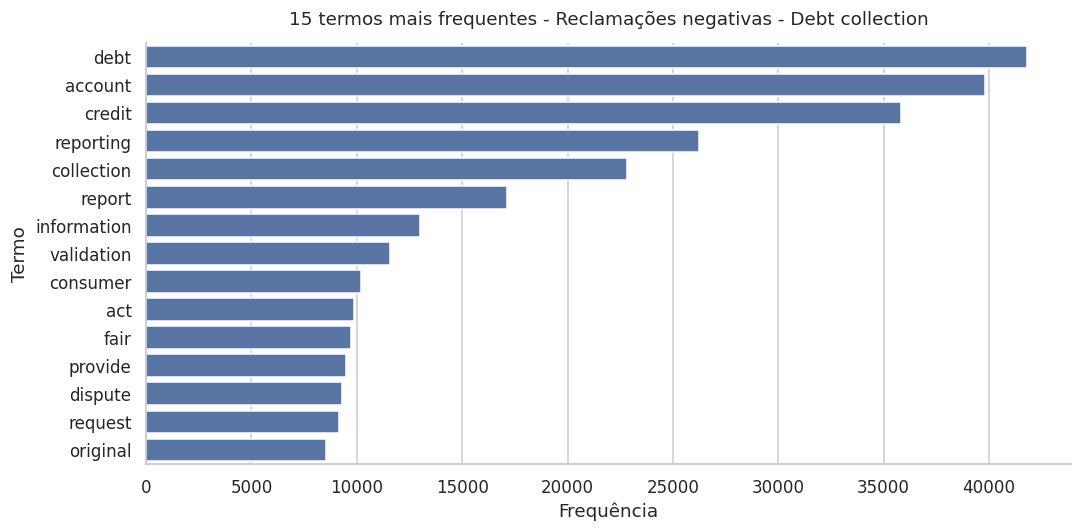

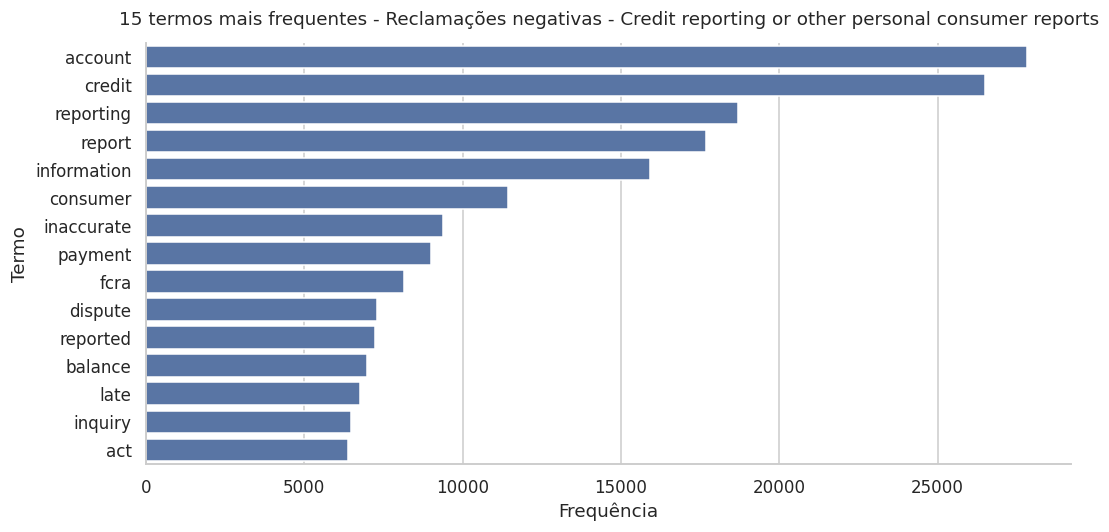

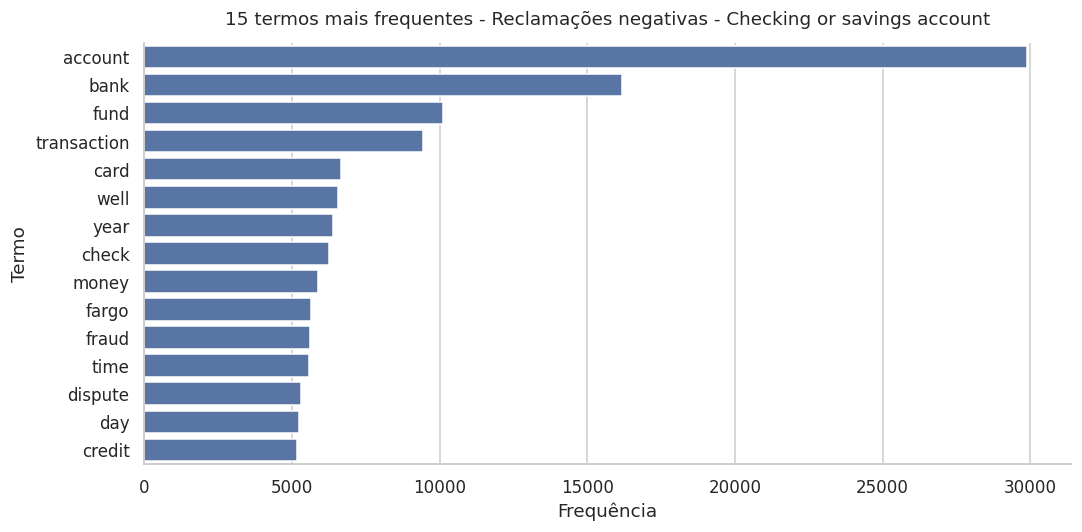

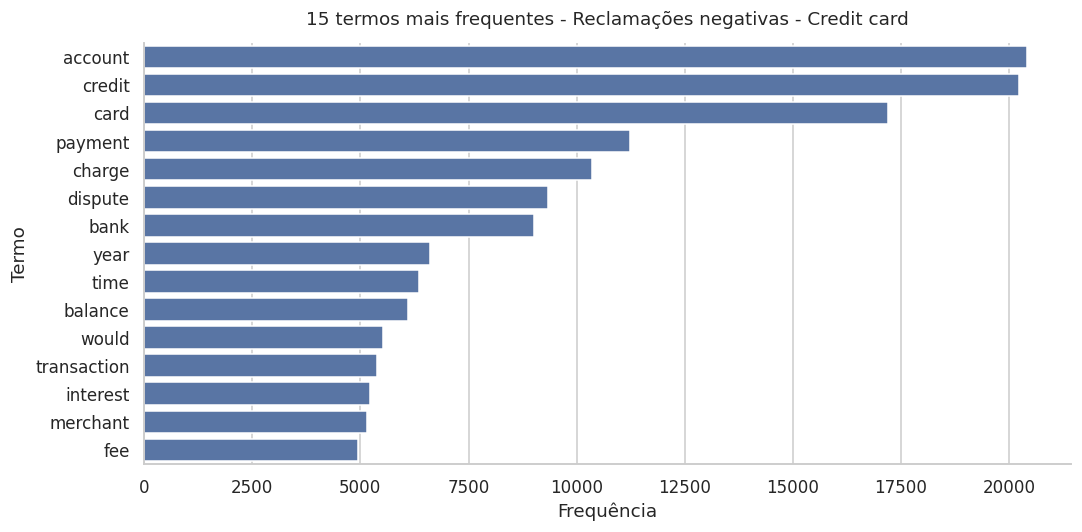

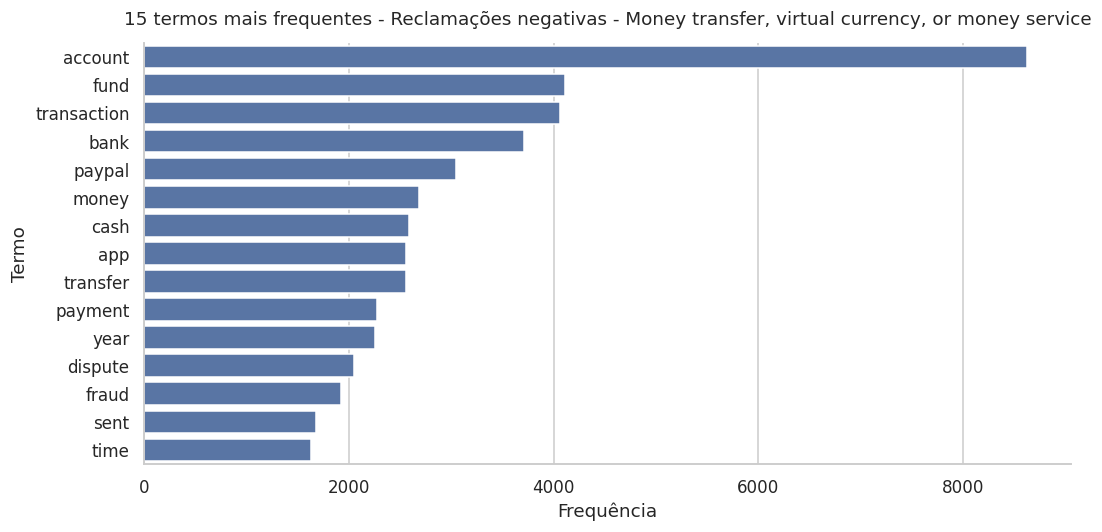

,Cobrança indevida,Fraude / transação não autorizada,Atendimento / suporte,Problemas com crédito / empréstimo,Reembolso / estorno,Erro operacional / sistema
Product,,,,,,
Debt collection,17462,6720,8772,79606,10222,3530
Credit reporting or other personal consumer reports,14010,8232,1084,30328,7340,5954
Checking or savings account,13164,12146,9872,6316,9564,6720
Credit card,37236,8398,12650,23328,14570,7738
"Money transfer, virtual currency, or money service",4284,4472,3668,1094,4094,2518


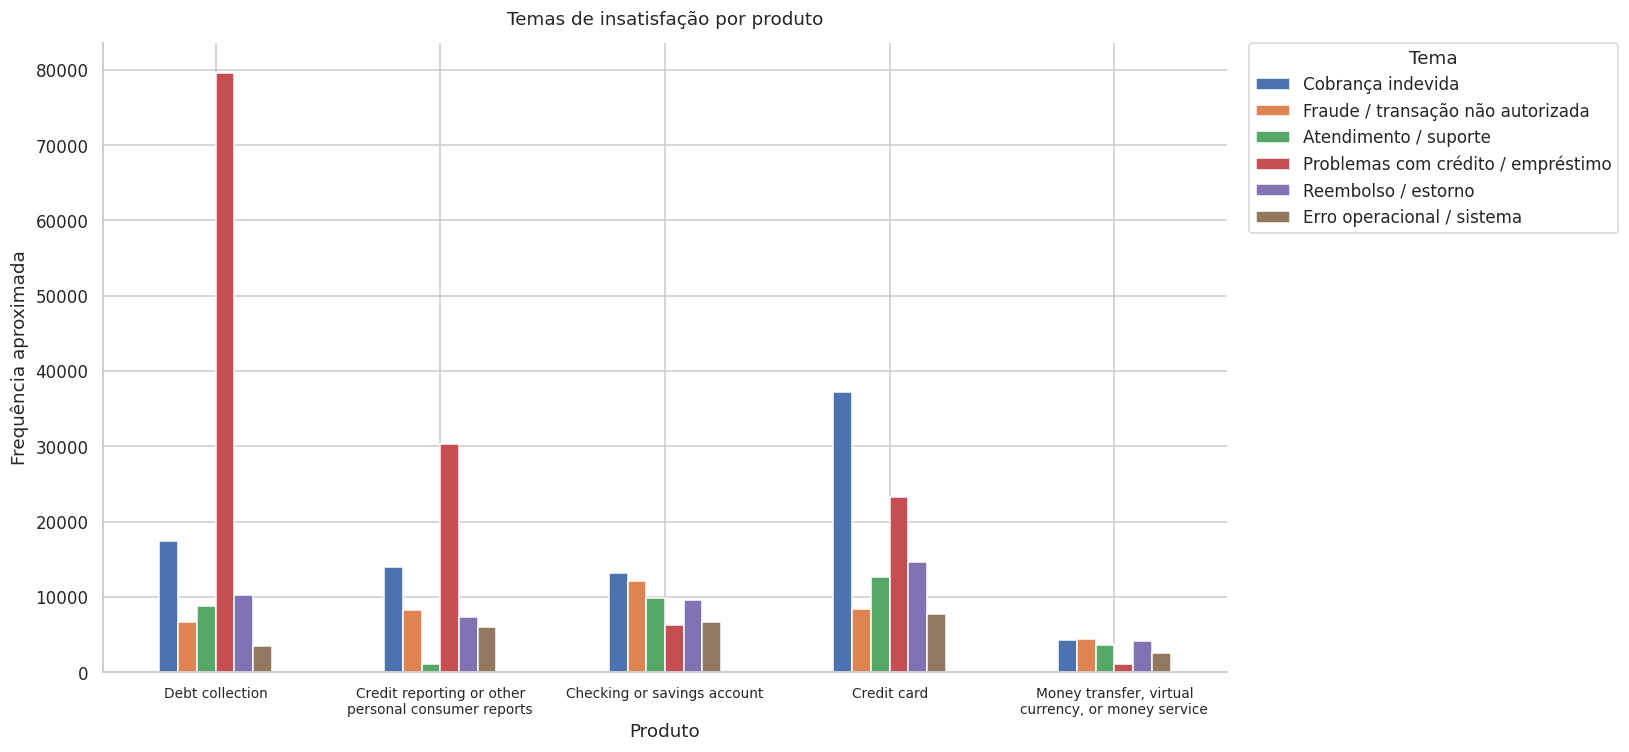

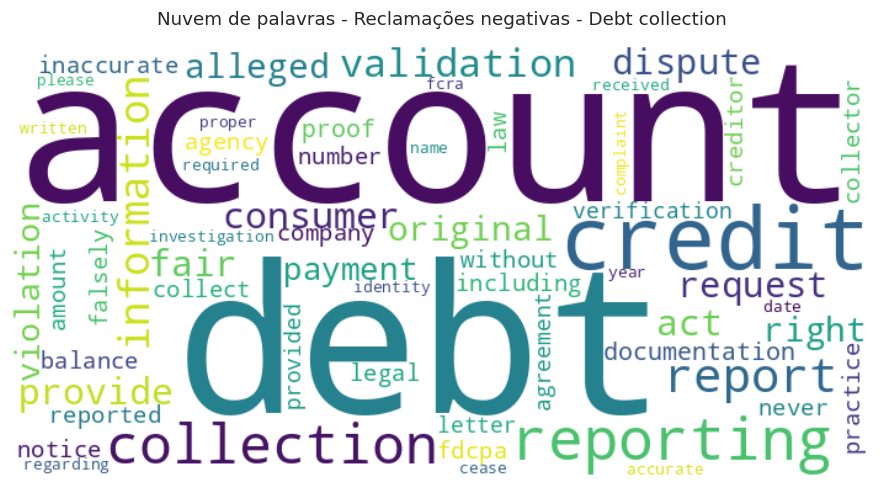

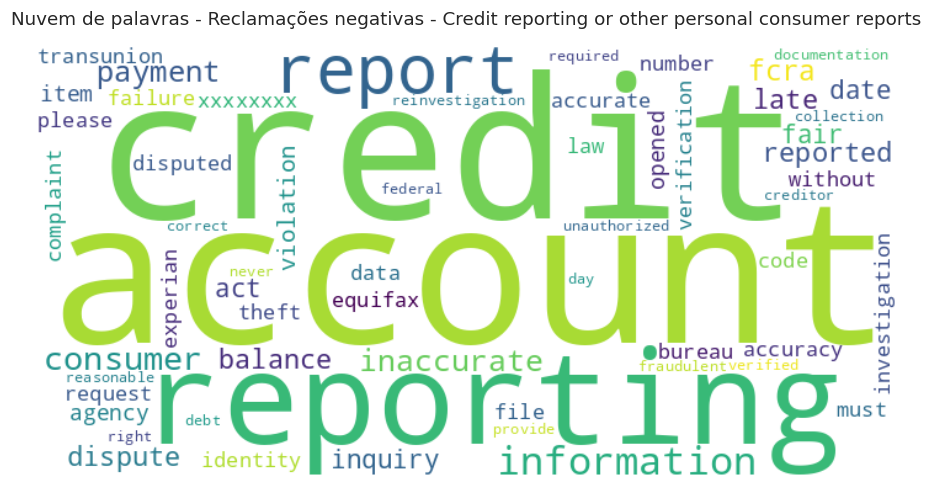

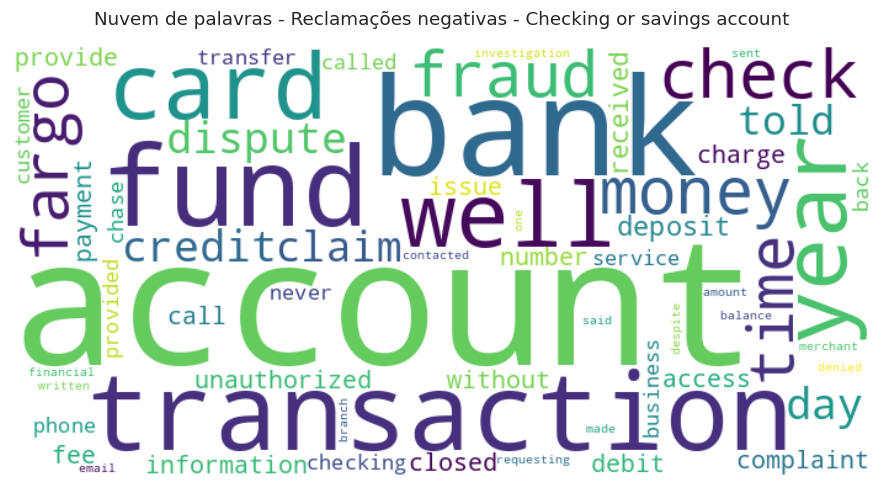

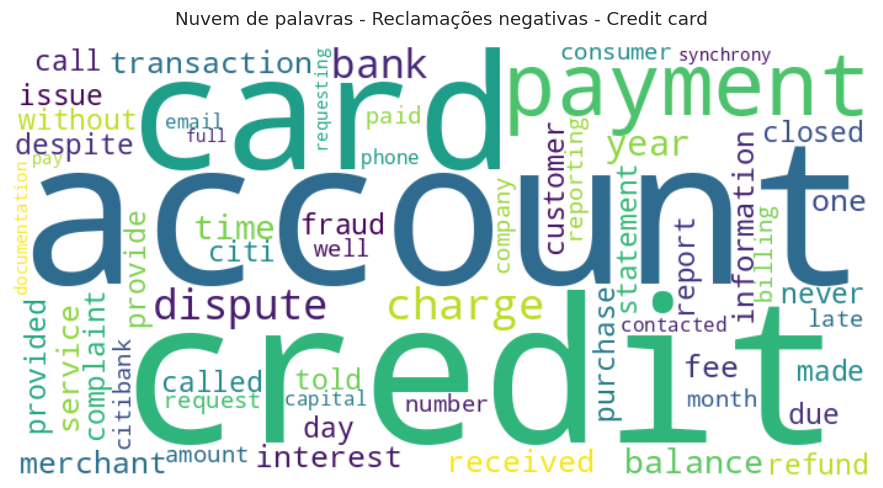

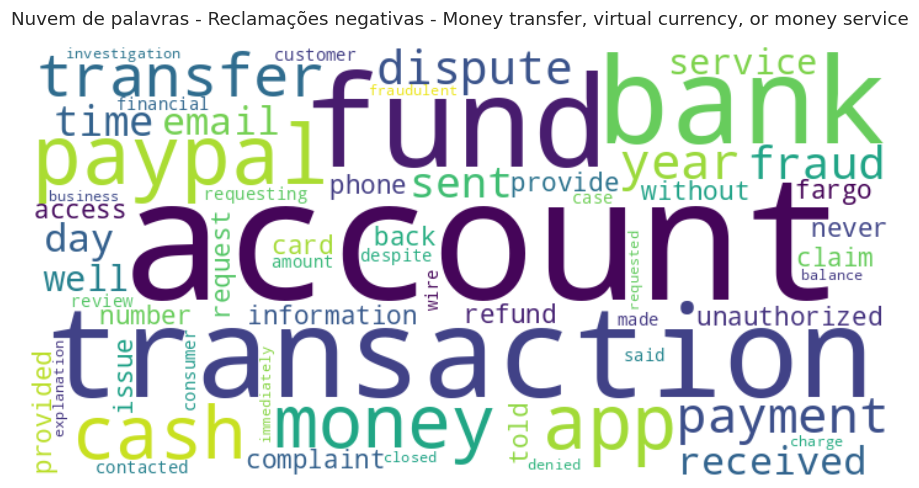

In [8]:
# ============================
# 9. ANÁLISE DAS DORES DOS CLIENTES
# ============================
# Esta seção consolida a análise exploratória das reclamações,
# destacando a distribuição de sentimentos por produto, os termos
# mais frequentes nas reclamações negativas, os principais temas
# de insatisfação e as nuvens de palavras por categoria.

from collections import Counter
import textwrap

# 9.1 Distribuição de sentimentos por produto
# Agrupa as reclamações por produto e sentimento para visualizar
# quais categorias concentram maior volume de avaliações negativas.
sentiment_by_product = (
    df.groupby(["Product", "sentiment"])
      .size()
      .unstack(fill_value=0)
)

if "negative" in sentiment_by_product.columns:
    sentiment_by_product = sentiment_by_product.sort_values(by="negative", ascending=True)

top_products_plot = sentiment_by_product.tail(10)

ax = top_products_plot.plot(kind="barh", figsize=(12, 7))
ax.set_title("Distribuição de sentimentos por produto", pad=12)
ax.set_xlabel("Quantidade de reclamações")
ax.set_ylabel("Produto")
ax.tick_params(axis="y", labelsize=9)

ax.legend(
    title="Sentimento",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.tight_layout()
plt.show()
print("\n")

# 9.2 Termos mais frequentes em reclamações negativas por produto
# Seleciona os produtos com maior volume de reclamações negativas
# e exibe os termos mais recorrentes em cada categoria.
top_negative_products = (
    df.loc[df["sentiment"] == "negative", "Product"]
      .value_counts()
      .head(5)
      .index
)

for product in top_negative_products:
    subset = df[
        (df["sentiment"] == "negative") &
        (df["Product"] == product)
    ]

    words = [
        word for word in " ".join(subset["clean_text"]).split()
        if word.lower() != "xxxx"
    ]

    word_freq = Counter(words)
    top_terms = pd.DataFrame(word_freq.most_common(15), columns=["word", "count"])

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=top_terms, x="count", y="word")
    ax.set_title(f"15 termos mais frequentes - Reclamações negativas - {product}", pad=12)
    ax.set_xlabel("Frequência")
    ax.set_ylabel("Termo")
    plt.tight_layout()
    plt.show()
    print("\n")

# 9.3 Identificação de temas de insatisfação por produto
# Agrupa palavras-chave em temas para facilitar a interpretação
# dos principais tipos de problema relatados pelos consumidores.
themes = {
    "Cobrança indevida": ["charge", "charged", "fee", "billing", "interest", "payment"],
    "Fraude / transação não autorizada": ["fraud", "unauthorized", "scam", "identity", "stolen"],
    "Atendimento / suporte": ["service", "support", "call", "representative", "agent"],
    "Problemas com crédito / empréstimo": ["loan", "mortgage", "credit", "debt", "limit"],
    "Reembolso / estorno": ["refund", "dispute", "reversal", "returned", "chargeback"],
    "Erro operacional / sistema": ["error", "wrong", "incorrect", "problem", "issue"]
}

theme_results = []

for product in top_negative_products:
    subset = df[
        (df["sentiment"] == "negative") &
        (df["Product"] == product)
    ]

    text_words = [
        word for word in " ".join(subset["clean_text"]).split()
        if word.lower() != "xxxx"
    ]

    word_counts = Counter(text_words)

    row = {"Product": product}
    for theme, keywords in themes.items():
        row[theme] = sum(word_counts[word] for word in keywords)

    theme_results.append(row)

theme_df = pd.DataFrame(theme_results).set_index("Product")
display(theme_df)

ax = theme_df.plot(kind="bar", figsize=(15, 7))
ax.set_title("Temas de insatisfação por produto", pad=12)
ax.set_xlabel("Produto")
ax.set_ylabel("Frequência aproximada")

wrapped_labels_93 = [
    "\n".join(textwrap.wrap(label.get_text(), width=28))
    for label in ax.get_xticklabels()
]
ax.set_xticklabels(wrapped_labels_93, rotation=0, ha="center", fontsize=9)

ax.legend(
    title="Tema",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.
)

plt.tight_layout()
plt.show()
print("\n")

# 9.4 Nuvens de palavras por produto
# Gera uma nuvem de palavras por produto, sempre uma por vez,
# para facilitar a leitura e comparação visual entre categorias.
for product in top_negative_products:
    product_words = [
        word for word in df.loc[
            (df["sentiment"] == "negative") & (df["Product"] == product),
            "clean_text"
        ].str.cat(sep=" ").split()
        if word.lower() != "xxxx"
    ]

    product_text = " ".join(product_words)

    if product_text.strip():
        wc = WordCloud(
            width=700,
            height=350,
            background_color="white",
            colormap="viridis",
            max_words=60,
            collocations=False
        ).generate(product_text)

        plt.figure(figsize=(9, 4.8))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Nuvem de palavras - Reclamações negativas - {product}", pad=14)
        plt.tight_layout(pad=2.0)
        plt.show()
        print("\n")